# 30_meta_1d_mass_rl2.ipynb — Phase 3 (1D Kütle, RL² Meta-RL, Sabit Hedef)

Bu defterde çok basit bir fiziksel sistem üzerinde RL² tarzı meta-öğrenme yapıyoruz:

- Ortam: 1D kütle (arabacık) — state: (x, v)
- Aksiyon: sürekli kuvvet u (sağa / sola itme)
- Dinamikler: x_{t+1} = x_t + v_t dt, v_{t+1} = v_t + (u_t / m - b v_t) dt
- Ödül: r_t = -|x_t - x_goal| - λ_u u_t^2 - λ_v v_t^2
- Task varyasyonu: sadece kütle m değişiyor (hafif / orta / ağır)
- Sürtünme b sabit, hedef x_goal sabit.
- Yöntem: RL² tarzı GRU policy + basit PPO güncellemesi.

Amaç: Ajan, geçmiş giriş-çıkışlardan bu sistemin hafif mi ağır mı olduğunu içsel durumu z_t üzerinden çıkarıp, epizot içinde daha iyi kontrol etmeyi öğreniyor mu?

## 1) Kurulum (gerekirse)

Gerekirse şu komutu açıp çalıştırabilirsin:

```bash
%pip install -U torch numpy matplotlib tensorboard pandas tqdm scikit-learn
```

In [1]:
# %pip install -U torch numpy matplotlib tensorboard pandas tqdm scikit-learn
print("Kurulum hücresi (gerektiğinde aktif et).")

Kurulum hücresi (gerektiğinde aktif et).


## 2) Kütüphaneler, Faz Ayarları ve Klasör Yapısı

Klasör şeması önceki defterlerle uyumlu:

```text
runs/Phase 3/30_meta_1d_mass_rl2/<RUN_ID>/
  ├─ monitor/
  ├─ checkpoints/
  └─ tb/
```

In [2]:
import os, time, uuid, json, random, warnings, pathlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.normal import Normal
from torch.utils.tensorboard import SummaryWriter

from tqdm import trange, tqdm
from sklearn.manifold import TSNE

print("Python   ", f"{os.sys.version.split()[0]}")
print("NumPy    ", np.__version__)
print("PyTorch  ", torch.__version__)
print("CUDA     ", torch.cuda.is_available(), "| MPS", torch.backends.mps.is_available())

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Device   ", device)

# Faz / Notebook bilgisi
PHASE    = "Phase 3"
STEP     = "3A-1D-Mass-RL2-SabitHedef"
NOTEBOOK = "30_meta_1d_mass_rl2"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Meta-RL hiperparametreleri (toy, hızlı deney için düşük değerler)
META_BATCH_SIZE   = 8      # her meta-iterasyonda kaç farklı task (farklı m)
EPISODES_PER_TASK = 4      # her task için ardışık epizot sayısı (aynı GRU hidden state)
ROLLOUT_LEN       = 100    # her epizotta max step
TOTAL_ITERS       = 200    # meta-iterasyon sayısı
GAMMA             = 0.99
LAMBDA_GAE        = 0.95
PPO_EPOCHS        = 4
PPO_CLIP          = 0.2
PPO_LR            = 3e-4

HIDDEN_SIZE       = 64     # GRU gizli boyutu (1D toy için yeterli)

# Ortam parametreleri
DT          = 0.05
MAX_STEPS   = ROLLOUT_LEN
ACTION_LOW  = -2.0
ACTION_HIGH =  2.0
LAMBDA_U    = 0.01
LAMBDA_V    = 0.01

# Task dağılımı: sadece kütle değişiyor, sürtünme ve hedef sabit
M_VALUES   = [0.5, 1.0, 2.0]  # hafif / orta / ağır
B_FIXED    = 0.3              # sabit viskoz sürtünme
X_GOAL_FIX = 2.0              # sabit hedef konum (örneğin sağda)

# Klasörler
RUN_ID    = time.strftime('%Y%m%d-%H%M%S') + f"-{uuid.uuid4().hex[:6]}"
ROOT_DIR  = os.path.join("runs", PHASE, NOTEBOOK, RUN_ID)
CKPT_DIR  = os.path.join(ROOT_DIR, "checkpoints")
MON_DIR   = os.path.join(ROOT_DIR, "monitor")
TB_DIR    = os.path.join(ROOT_DIR, "tb")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(MON_DIR,  exist_ok=True)
os.makedirs(TB_DIR,   exist_ok=True)

writer = SummaryWriter(TB_DIR)
print("ROOT_DIR:", ROOT_DIR)

Python    3.9.6
NumPy     2.0.2
PyTorch   2.7.1
CUDA      False | MPS True
Device    mps
ROOT_DIR: runs/Phase 3/30_meta_1d_mass_rl2/20251114-145846-697e0b


## 3) 1D Point-Mass Ortamı ve Sadece Kütle m Varyasyonu

Dinamikler:
- x_{t+1} = x_t + v_t * dt
- v_{t+1} = v_t + (u_t / m - b * v_t) * dt

Ödül:
- r_t = -|x_t - x_goal| - lambda_u * u_t^2 - lambda_v * v_t^2

Task değişimi: sadece m değişiyor (hafif, orta, ağır); b ve x_goal sabit. RL² ajanı, geçmiş deneyden bu sistemin hafif mi ağır mı olduğunu çıkarıp policy’yi buna göre uyarlamaya çalışıyor.

In [3]:
from dataclasses import dataclass

@dataclass
class MassTask:
    m: float
    b: float
    x_goal: float

def sample_task():
    # Sadece kütle m değişiyor; b ve x_goal sabit
    m = random.choice(M_VALUES)
    b = B_FIXED
    xg = X_GOAL_FIX
    return MassTask(m, b, xg)

class OneDMassEnv:
    def __init__(self, task: MassTask, dt=DT, max_steps=MAX_STEPS,
                 action_low=ACTION_LOW, action_high=ACTION_HIGH,
                 lambda_u=LAMBDA_U, lambda_v=LAMBDA_V):
        self.task = task
        self.dt = dt
        self.max_steps = max_steps
        self.action_low = action_low
        self.action_high = action_high
        self.lambda_u = lambda_u
        self.lambda_v = lambda_v
        self.state = None
        self.t = 0

    def reset(self, seed=None):
        if seed is not None:
            np.random.seed(seed)
        x0 = np.random.uniform(-2.0, 2.0)
        v0 = np.random.uniform(-1.0, 1.0)
        self.state = np.array([x0, v0], dtype=np.float32)
        self.t = 0
        return self.state.copy(), {}

    def step(self, u):
        u = float(np.clip(u, self.action_low, self.action_high))
        x, v = self.state
        m = self.task.m
        b = self.task.b
        dt = self.dt

        nx = x + v * dt
        nv = v + (u / m - b * v) * dt
        self.state = np.array([nx, nv], dtype=np.float32)
        self.t += 1

        dist = abs(nx - self.task.x_goal)
        r = - dist - self.lambda_u * (u**2) - self.lambda_v * (nv**2)

        done = False
        if self.t >= self.max_steps:
            done = True
        if abs(nx) > 5.0:
            done = True

        info = {"task": self.task}
        return self.state.copy(), float(r), done, False, info

    def close(self):
        # Gym API uyumluluğu için boş close
        pass

# Hızlı test
test_task = sample_task()
env = OneDMassEnv(test_task)
s, _ = env.reset(seed=SEED)
print("Initial state:", s, "| task:", test_task)
for _ in range(3):
    ns, r, d, tr, info = env.step(0.0)
    print("step ->", ns, "r=", r, "done=", d)
    if d:
        break
env.close()
del env

Initial state: [-0.5018395   0.90142864] | task: MassTask(m=2.0, b=0.3, x_goal=2.0)
step -> [-0.4567681  0.8879072] r= -2.4646518230438232 done= False
step -> [-0.41237274  0.8745886 ] r= -2.4200217723846436 done= False
step -> [-0.3686433  0.8614698] r= -2.3760645389556885 done= False


## 4) RL² Girdisi: Genişletilmiş Gözlem

RL² fikri için policy’ye doğrudan task parametresi (m) vermiyoruz. Bunun yerine giriş:

- x: konum
- v: hız
- a_prev: bir önceki aksiyon
- r_prev: bir önceki ödül
- d_prev: bir önceki adımın done bayrağı

Yani policy girdisi:

    aug_obs = [x, v, a_prev, r_prev, d_prev]

GRU bu sekansı görüp içsel durum z_t üzerinden “bu sistem hafif mi ağır mı?” bilgisini kodlamaya çalışıyor.

In [4]:
def make_initial_history(action_dim: int):
    prev_a = np.zeros(action_dim, dtype=np.float32)
    prev_r = np.array([0.0], dtype=np.float32)
    prev_d = np.array([0.0], dtype=np.float32)
    return prev_a, prev_r, prev_d

def augment_obs(obs, prev_a, prev_r, prev_d):
    return np.concatenate([obs.astype(np.float32), prev_a, prev_r, prev_d], axis=-1).astype(np.float32)

# Boyut testi
tmp_task = sample_task()
tmp_env  = OneDMassEnv(tmp_task)
s0, _ = tmp_env.reset(seed=SEED)
act_dim = 1
pa, pr, pd = make_initial_history(act_dim)
aug = augment_obs(s0, pa, pr, pd)
print("obs dim:", s0.shape, "-> aug dim:", aug.shape)
tmp_env.close()
del tmp_env

obs dim: (2,) -> aug dim: (5,)


## 5) RL² Çekirdeği: `src/meta/rl2_core.py` (GRU tabanlı policy)

Bu hücre `src/meta/rl2_core.py` dosyasını üretir. İçinde:
- `RL2RecurrentPolicy`: GRU tabanlı policy + value ağı
- Girdi: genişletilmiş gözlem (aug_obs)
- Çıkış: action, log_prob, value, next_hidden

Aynı dosyayı ileride başka defterlerde de kullanabilirsin.

In [5]:
SRC_RL2 = pathlib.Path("src/meta/rl2_core.py")
SRC_RL2.parent.mkdir(parents=True, exist_ok=True)

rl2_core_code = '''
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.normal import Normal

class RL2RecurrentPolicy(nn.Module):
    """GRU tabanlı RL² policy + value ağı.
    Girdi: x_t (ör. [obs, a_{t-1}, r_{t-1}, d_{t-1}])
    Çıkış: action, log_prob, value, next_hidden
    """
    def __init__(self, input_dim:int, action_dim:int, hidden_size:int=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.action_dim  = action_dim

        self.fc_in = nn.Linear(input_dim, hidden_size)
        self.gru   = nn.GRU(hidden_size, hidden_size, batch_first=True)

        self.fc_pi = nn.Linear(hidden_size, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))
        self.fc_v  = nn.Linear(hidden_size, 1)

    def initial_hidden(self, batch_size:int=1, device:str="cpu"):
        return torch.zeros(1, batch_size, self.hidden_size, device=device)

    def forward_step(self, x_t:torch.Tensor, h:torch.Tensor):
        """Tek zaman adımı için ileri geçiş.
        x_t: (B, input_dim), h: (1, B, H)
        """
        z = F.relu(self.fc_in(x_t))
        z = z.unsqueeze(1)              # (B,1,H)
        out, h_next = self.gru(z, h)    # out: (B,1,H)
        out = out.squeeze(1)            # (B,H)

        mean = self.fc_pi(out)
        std  = self.log_std.exp().unsqueeze(0)
        dist = Normal(mean, std)
        action = dist.sample()
        logp   = dist.log_prob(action).sum(dim=-1)
        value  = self.fc_v(out).squeeze(-1)
        return action, logp, value, h_next

    def act_deterministic(self, x_t:torch.Tensor, h:torch.Tensor):
        z = F.relu(self.fc_in(x_t))
        z = z.unsqueeze(1)
        out, h_next = self.gru(z, h)
        out = out.squeeze(1)
        mean = self.fc_pi(out)
        value = self.fc_v(out).squeeze(-1)
        return mean, value, h_next
'''

SRC_RL2.write_text(rl2_core_code, encoding="utf-8")
print("Yazıldı:", SRC_RL2)

import importlib.util
spec = importlib.util.spec_from_file_location("meta.rl2_core", SRC_RL2)
rl2_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rl2_module)
RL2RecurrentPolicy = rl2_module.RL2RecurrentPolicy
print("RL2RecurrentPolicy yüklendi.")

Yazıldı: src/meta/rl2_core.py
RL2RecurrentPolicy yüklendi.


## 6) RL² PPO Ajanı (Basitleştirilmiş)

- `RL2Agent.collect_batch`: bir meta-batch (birden fazla farklı m değeri) rollout toplar.
- Aynı task içindeki epizotlar boyunca GRU hidden state sıfırlanmaz (task-level hafıza).
- `compute_gae`: basit GAE-Lambda hesaplar (tek büyük trajectory üzerinde, done ile bölünüyor).
- `ppo_update`: basit PPO oran kaybı ile policy ve value güncellenir.

Bu kod araştırma / tez amaçlıdır; SB3 kadar optimize değildir ama RL² fikrini göstermeye yeterli bir iskelettir.

In [6]:
class RL2Agent:
    def __init__(self, input_dim, action_dim, hidden_size=HIDDEN_SIZE, lr=PPO_LR, device=device):
        self.device = device
        self.policy = RL2RecurrentPolicy(input_dim, action_dim, hidden_size).to(device)
        self.optim  = torch.optim.Adam(self.policy.parameters(), lr=lr)

    def collect_batch(self, meta_batch_size=META_BATCH_SIZE, episodes_per_task=EPISODES_PER_TASK,
                      rollout_len=ROLLOUT_LEN):
        obs_buf, act_buf, logp_buf, rew_buf, val_buf, done_buf = [], [], [], [], [], []
        z_buf = []
        m_buf = []

        ep_returns_per_task = []
        step_rewards_for_adapt = []  # (task, ep, step) reward listeleri

        for task_idx in range(meta_batch_size):
            task = sample_task()
            env  = OneDMassEnv(task)
            action_dim = 1

            # GRU hidden state: aynı task içindeki epizotlar arasında taşınır
            h = self.policy.initial_hidden(batch_size=1, device=self.device)

            task_ep_returns = []
            for ep in range(episodes_per_task):
                s, _ = env.reset(seed=SEED + task_idx*100 + ep)
                prev_a, prev_r, prev_d = make_initial_history(action_dim)
                ep_ret = 0.0
                step_rewards = []

                for t in range(rollout_len):
                    aug = augment_obs(s, prev_a, prev_r, prev_d)
                    x_t = torch.tensor(aug, dtype=torch.float32, device=self.device).unsqueeze(0)
                    with torch.no_grad():
                        a_t, logp_t, v_t, h = self.policy.forward_step(x_t, h)
                    a_np = a_t.squeeze(0).cpu().numpy()
                    ns, r, done, trunc, info = env.step(a_np[0])

                    obs_buf.append(aug)
                    act_buf.append(a_np)
                    logp_buf.append(logp_t.cpu().numpy())
                    rew_buf.append(r)
                    val_buf.append(v_t.cpu().numpy())
                    done_flag = float(done or trunc)
                    done_buf.append(done_flag)

                    z_buf.append(h.squeeze(0).squeeze(0).detach().cpu().numpy())
                    m_buf.append(task.m)

                    ep_ret += r
                    step_rewards.append(r)

                    prev_a = np.array([a_np[0]], dtype=np.float32)
                    prev_r = np.array([r], dtype=np.float32)
                    prev_d = np.array([done_flag], dtype=np.float32)
                    s = ns
                    if done or trunc:
                        break

                task_ep_returns.append(ep_ret)
                step_rewards_for_adapt.append(step_rewards)

            ep_returns_per_task.append(task_ep_returns)
            env.close()

        batch = {
            "obs":   torch.tensor(np.stack(obs_buf), dtype=torch.float32, device=self.device),
            "act":   torch.tensor(np.stack(act_buf), dtype=torch.float32, device=self.device),
            "logp":  torch.tensor(np.stack(logp_buf).squeeze(-1), dtype=torch.float32, device=self.device),
            "rew":   torch.tensor(np.array(rew_buf), dtype=torch.float32, device=self.device),
            "val":   torch.tensor(np.stack(val_buf).squeeze(-1), dtype=torch.float32, device=self.device),
            "done":  torch.tensor(np.array(done_buf), dtype=torch.float32, device=self.device),
            "z":     torch.tensor(np.stack(z_buf), dtype=torch.float32, device=self.device),
            "m":     torch.tensor(np.array(m_buf), dtype=torch.float32, device=self.device)
        }
        return batch, ep_returns_per_task, step_rewards_for_adapt

    def compute_gae(self, rew, val, done, gamma=GAMMA, lam=LAMBDA_GAE):
        """Basit GAE-Lambda hesaplaması.
        rew, val, done: uzunluk T (tek uzun trajectory, done ile epizotlar ayrılıyor).
        """
        T = len(rew)
        adv = torch.zeros(T, dtype=torch.float32, device=rew.device)
        last_gae = 0.0
        for t in reversed(range(T)):
            nonterminal = 1.0 - done[t]
            if t == T - 1:
                next_value = 0.0
            else:
                next_value = val[t + 1]
            delta = rew[t] + gamma * next_value * nonterminal - val[t]
            last_gae = delta + gamma * lam * nonterminal * last_gae
            adv[t] = last_gae
        ret = adv + val
        return adv, ret

    def ppo_update(self, batch, epochs=PPO_EPOCHS, clip_ratio=PPO_CLIP):
        obs = batch["obs"]
        act = batch["act"]
        old_logp = batch["logp"]
        rew = batch["rew"]
        val = batch["val"]
        done = batch["done"]

        adv, ret = self.compute_gae(rew, val, done)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        N = len(obs)
        idxs = np.arange(N)

        for ep in range(epochs):
            np.random.shuffle(idxs)
            for start in range(0, N, 256):
                j = idxs[start:start+256]
                x = obs[j]
                a = act[j]
                adv_b = adv[j]
                ret_b = ret[j]
                old_logp_b = old_logp[j]

                h0 = self.policy.initial_hidden(batch_size=len(j), device=self.device)
                act_pi, logp_pi, v_pi, _ = self.policy.forward_step(x, h0)

                dist = Normal(act_pi, self.policy.log_std.exp().unsqueeze(0))
                logp = dist.log_prob(a).sum(dim=-1)
                ratio = torch.exp(logp - old_logp_b)

                surr1 = ratio * adv_b
                surr2 = torch.clamp(ratio, 1.0-clip_ratio, 1.0+clip_ratio) * adv_b
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss  = F.mse_loss(v_pi, ret_b)
                entropy     = dist.entropy().sum(dim=-1).mean()

                loss = policy_loss + 0.5*value_loss - 0.01*entropy

                self.optim.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
                self.optim.step()

        return float(policy_loss.item()), float(value_loss.item())

# Ajanı oluştur
input_dim = 2 + 1 + 1 + 1  # (x, v) + a_prev + r_prev + d_prev
action_dim = 1
agent = RL2Agent(input_dim=input_dim, action_dim=action_dim, hidden_size=HIDDEN_SIZE, lr=PPO_LR, device=device)
print("RL2Agent hazır.")

RL2Agent hazır.


## 7) Eğitim Döngüsü: Meta-RL², Regret ve Adaptasyon Toplama

Her meta-iterasyonda:

1. Farklı m değerlerine sahip `META_BATCH_SIZE` kadar task örneklenir.
2. Her task için `EPISODES_PER_TASK` epizot oynanır; aynı task içindeki epizotlar boyunca GRU hidden state taşınır.
3. PPO update yapılır.
4. Task bazında:
   - Epizot return’larından en iyisi `best_return` olarak alınır.
   - Kümülatif regret = sum(best_return - return_ep) hesaplanır.
   - Adaptasyon hızı = best_return’in %80’ine ulaşılan ilk epizot index’i (kaçıncı epizotta toparlıyor?).
5. GRU gizli durum z_t ve kütle m loglanır (t-SNE için).

In [7]:
z_all = []
m_all = []

regret_history = []
adapt_speed_history = []

for it in range(1, TOTAL_ITERS+1):
    batch, ep_returns_per_task, step_rewards_for_adapt = agent.collect_batch()
    pi_loss, v_loss = agent.ppo_update(batch)

    # z_t ve kütleleri topla (t-SNE için)
    z_all.append(batch["z"].detach().cpu().numpy())
    m_all.append(batch["m"].detach().cpu().numpy())

    # Regret ve adaptasyon hızı
    task_regrets = []
    task_adapt_steps = []
    for task_ep in ep_returns_per_task:
        best = max(task_ep)
        regrets = [best - r for r in task_ep]
        task_regrets.append(sum(regrets))
        thr = best * 0.8
        adapt_idx = len(task_ep)
        for j, r in enumerate(task_ep):
            if r >= thr:
                adapt_idx = j+1
                break
        task_adapt_steps.append(adapt_idx)

    mean_regret = float(np.mean(task_regrets))
    mean_adapt  = float(np.mean(task_adapt_steps))
    regret_history.append(mean_regret)
    adapt_speed_history.append(mean_adapt)

    writer.add_scalar("train/pi_loss", pi_loss, it)
    writer.add_scalar("train/v_loss",  v_loss, it)
    writer.add_scalar("metrics/regret", mean_regret, it)
    writer.add_scalar("metrics/adaptation_steps", mean_adapt, it)

    if it % 10 == 0 or it == 1:
        print(f"[Iter {it:04d}] pi_loss={pi_loss:.3f} v_loss={v_loss:.3f} regret={mean_regret:.2f} adapt={mean_adapt:.2f}")

z_all = np.concatenate(z_all, axis=0)
m_all = np.concatenate(m_all, axis=0)
print("Toplam z_t sayısı:", z_all.shape[0])

[Iter 0001] pi_loss=0.244 v_loss=999.659 regret=488.20 adapt=4.00
[Iter 0010] pi_loss=0.120 v_loss=2132.936 regret=570.71 adapt=4.00
[Iter 0020] pi_loss=0.142 v_loss=1771.476 regret=468.09 adapt=4.00
[Iter 0030] pi_loss=0.066 v_loss=1590.872 regret=485.31 adapt=4.00
[Iter 0040] pi_loss=0.158 v_loss=2050.570 regret=542.12 adapt=4.00
[Iter 0050] pi_loss=0.277 v_loss=1344.618 regret=404.36 adapt=4.00
[Iter 0060] pi_loss=1.032 v_loss=1484.880 regret=523.95 adapt=4.00
[Iter 0070] pi_loss=-0.044 v_loss=1247.205 regret=575.14 adapt=4.00
[Iter 0080] pi_loss=0.033 v_loss=1076.071 regret=514.21 adapt=4.00
[Iter 0090] pi_loss=0.140 v_loss=1610.694 regret=615.18 adapt=4.00
[Iter 0100] pi_loss=0.232 v_loss=632.391 regret=546.78 adapt=4.00
[Iter 0110] pi_loss=0.338 v_loss=1370.716 regret=602.76 adapt=4.00
[Iter 0120] pi_loss=0.182 v_loss=1469.358 regret=523.65 adapt=4.00
[Iter 0130] pi_loss=0.086 v_loss=1526.583 regret=523.31 adapt=4.00
[Iter 0140] pi_loss=-0.392 v_loss=574.371 regret=481.64 adapt=4

## 8) Adaptation Curve (Epizot içi step’e göre ortalama ödül)

Eğitim sonrası policy’yi dondurup yeni task’lar üzerinde:
- Epizot içi step’e göre ortalama ödül eğrisine bakıyoruz.
- İdeal olarak ilk adımlarda reward düşük, birkaç adım sonra sistemin “ağır/hafif” olduğunu kavrayıp daha iyi davranış üretmeye başlamalı (curve yukarı kaymalı).

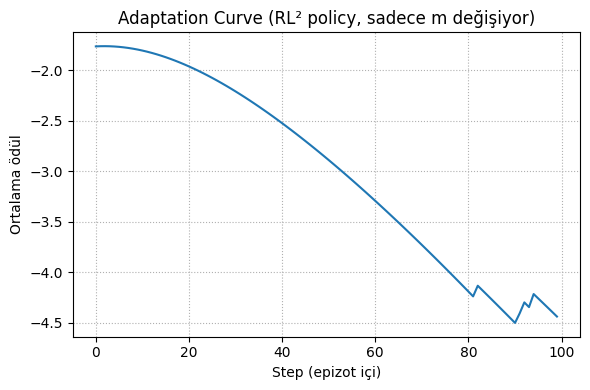

In [8]:
@torch.no_grad()
def evaluate_adaptation_curve(agent, n_tasks=20, episodes_per_task=1, horizon=ROLLOUT_LEN):
    rewards_per_step = [[] for _ in range(horizon)]
    for k in range(n_tasks):
        task = sample_task()
        env = OneDMassEnv(task)
        h = agent.policy.initial_hidden(batch_size=1, device=device)
        for ep in range(episodes_per_task):
            s, _ = env.reset(seed=SEED + 1000 + k*10 + ep)
            prev_a, prev_r, prev_d = make_initial_history(1)
            for t in range(horizon):
                aug = augment_obs(s, prev_a, prev_r, prev_d)
                x_t = torch.tensor(aug, dtype=torch.float32, device=device).unsqueeze(0)
                mean, _, h = agent.policy.act_deterministic(x_t, h)
                a_np = mean.squeeze(0).cpu().numpy()
                ns, r, done, trunc, info = env.step(a_np[0])
                if t < horizon:
                    rewards_per_step[t].append(r)
                prev_a = np.array([a_np[0]], dtype=np.float32)
                prev_r = np.array([r], dtype=np.float32)
                prev_d = np.array([float(done or trunc)], dtype=np.float32)
                s = ns
                if done or trunc:
                    break
        env.close()
    mean_rewards = np.array([np.mean(rs) if len(rs)>0 else 0.0 for rs in rewards_per_step])
    return mean_rewards

adapt_curve = evaluate_adaptation_curve(agent, n_tasks=20, episodes_per_task=1, horizon=ROLLOUT_LEN)
plt.figure(figsize=(6,4))
plt.plot(np.arange(len(adapt_curve)), adapt_curve)
plt.xlabel("Step (epizot içi)")
plt.ylabel("Ortalama ödül")
plt.title("Adaptation Curve (RL² policy, sadece m değişiyor)")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

## 9) z_t Gizli Durum t-SNE Görselleştirmesi (renk = kütle m)

Burada GRU’nun gizli durumu z_t’leri 2D’ye indirip, renkleri kütle m değerine göre boyuyoruz.

Eğer RL² başarılıysa, benzer kütlelere ait z_t’ler benzer bölgelerde kümelenmeye başlayabilir (örneğin hafif sistemler bir bölgede, ağır sistemler başka bölgede). Bu, RNN’in **m’yi içsel olarak kodladığını** gösteren bir işaret olarak yorumlanabilir.

t-SNE için örnek sayısı: 3000


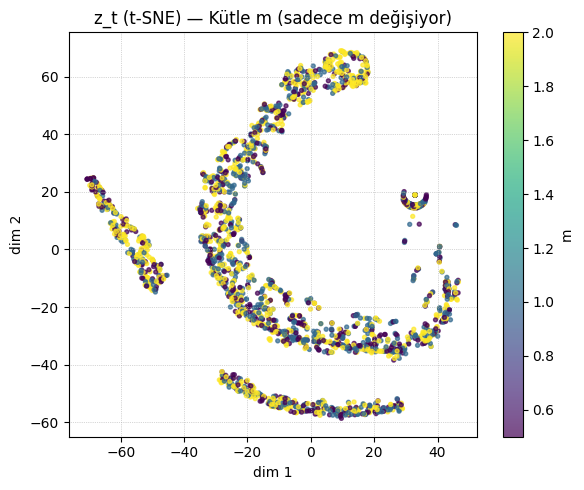

In [9]:
N_TSNE = min(3000, z_all.shape[0])
idx = np.random.choice(z_all.shape[0], size=N_TSNE, replace=False)
z_sample = z_all[idx]
m_sample = m_all[idx]

print("t-SNE için örnek sayısı:", z_sample.shape[0])

tsne = TSNE(n_components=2, perplexity=30.0, learning_rate=200.0, n_iter=1000, init="random")
z_2d = tsne.fit_transform(z_sample)

plt.figure(figsize=(6,5))
scatter = plt.scatter(z_2d[:,0], z_2d[:,1], c=m_sample, cmap="viridis", s=8, alpha=0.7)
plt.title("z_t (t-SNE) — Kütle m (sadece m değişiyor)")
plt.xlabel("dim 1"); plt.ylabel("dim 2")
cbar = plt.colorbar(scatter)
cbar.set_label("m")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

## 10) Meta-Regret ve Adaptasyon Hızı Grafikleri

Eğitim boyunca:
- Ortalama kümülatif regret (task başına)
- Ortalama adaptasyon epizot sayısı

eğrilerini çizerek RL² ajanının zamanla gerçekten daha hızlı adapte olup olmadığını görselleştiriyoruz.

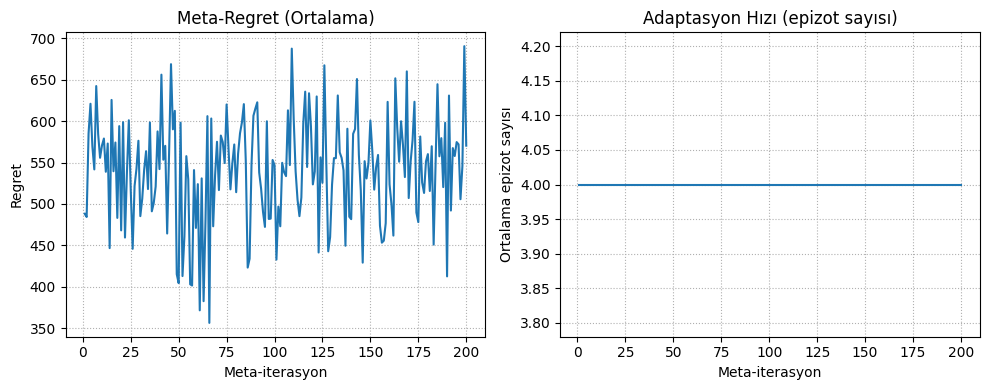

In [10]:
iters = np.arange(1, len(regret_history)+1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(iters, regret_history)
plt.title("Meta-Regret (Ortalama)")
plt.xlabel("Meta-iterasyon"); plt.ylabel("Regret")
plt.grid(True, linestyle=":")

plt.subplot(1,2,2)
plt.plot(iters, adapt_speed_history)
plt.title("Adaptasyon Hızı (epizot sayısı)")
plt.xlabel("Meta-iterasyon"); plt.ylabel("Ortalama epizot sayısı")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

## 11) Meta Bilgi Kaydı ve Kapanış

Koşunun meta bilgilerini `meta.json` dosyasına kaydedip TensorBoard writer’ı kapatıyoruz.

In [11]:
meta = {
    "phase": PHASE,
    "step": STEP,
    "notebook": NOTEBOOK,
    "env": "1D-mass-only-m",
    "seed": SEED,
    "run_id": RUN_ID,
    "root_dir": ROOT_DIR,
    "ckpt_dir": CKPT_DIR,
    "monitor_dir": MON_DIR,
    "tb_dir": TB_DIR,
    "rl2": {
        "hidden_size": HIDDEN_SIZE,
        "meta_batch_size": META_BATCH_SIZE,
        "episodes_per_task": EPISODES_PER_TASK,
        "rollout_len": ROLLOUT_LEN,
        "total_iters": TOTAL_ITERS,
        "gamma": GAMMA,
        "lambda_gae": LAMBDA_GAE,
        "ppo_epochs": PPO_EPOCHS,
        "ppo_clip": PPO_CLIP,
        "lr": PPO_LR
    }
}

os.makedirs(ROOT_DIR, exist_ok=True)
with open(os.path.join(ROOT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

writer.flush(); writer.close()
print(json.dumps(meta, indent=2))
print("Kapanış tamam.")

{
  "phase": "Phase 3",
  "step": "3A-1D-Mass-RL2-SabitHedef",
  "notebook": "30_meta_1d_mass_rl2",
  "env": "1D-mass-only-m",
  "seed": 42,
  "run_id": "20251114-145846-697e0b",
  "root_dir": "runs/Phase 3/30_meta_1d_mass_rl2/20251114-145846-697e0b",
  "ckpt_dir": "runs/Phase 3/30_meta_1d_mass_rl2/20251114-145846-697e0b/checkpoints",
  "monitor_dir": "runs/Phase 3/30_meta_1d_mass_rl2/20251114-145846-697e0b/monitor",
  "tb_dir": "runs/Phase 3/30_meta_1d_mass_rl2/20251114-145846-697e0b/tb",
  "rl2": {
    "hidden_size": 64,
    "meta_batch_size": 8,
    "episodes_per_task": 4,
    "rollout_len": 100,
    "total_iters": 200,
    "gamma": 0.99,
    "lambda_gae": 0.95,
    "ppo_epochs": 4,
    "ppo_clip": 0.2,
    "lr": 0.0003
  }
}
Kapanış tamam.
